   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup   

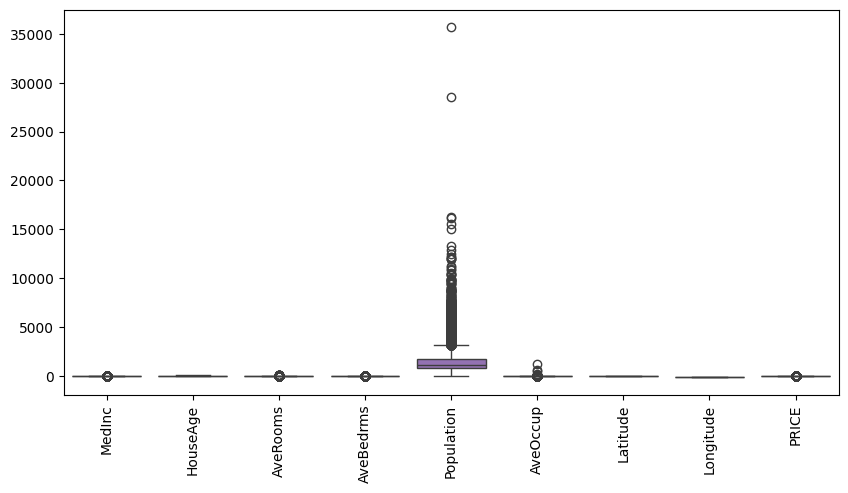

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['PRICE'] = housing.target

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

Q1 = df.quantile(0.25)

Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

X = df.drop('PRICE', axis=1)

y = df['PRICE']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'MSE', 'R2 Score']
)

print(results_df)

best_model = RandomForestRegressor()

best_model.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")

print(importance)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()